# Visualisation for machine learning

This notebook explores various visualisation techniques used in machine learning to understand data exploration, high-dimensional data and model performance using a real world dataset.

### Import libraries and data

In [109]:
# !pip install umap-learn
# !pip install xgboost
# !pip install --upgrade scikit-learn

In [110]:
from sklearn.datasets import load_wine

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
import umap.umap_ as umap
from sklearn.manifold import TSNE

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import label_binarize

import time
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [164]:
# Define custom style with larger fonts and bold titles
custom_style = {
    "axes.facecolor": "#595959",
    "axes.edgecolor": "#f2f2f2",
    "axes.labelcolor": "#f2f2f2",
    "figure.facecolor": "#595959",
    "grid.color": "#f2f2f2",
    "text.color": "#f2f2f2",
    "xtick.color": "#f2f2f2",
    "ytick.color": "#f2f2f2",
    "legend.frameon": False,
    "font.size": 16,  # Larger font size
    "axes.titlesize": 20,  # Larger title font
    "axes.titleweight": "bold",  # Bold plot titles
    "axes.labelsize": 18,  # Larger axis labels
    "xtick.labelsize": 14,  # Larger x-axis tick labels
    "ytick.labelsize": 14,  # Larger y-axis tick labels
}

# Apply the style globally
plt.rcParams.update(custom_style)
sns.set_style("darkgrid", custom_style)

In [112]:
# Load the dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


Target classes:
    
0: Class 0 represents Barolo wine, a red wine from the Piedmont region.

1: Class 1 represents Gavi wine, a white wine made from the Cortese grape variety.

2: Class 2 represents Grignolino wine, a red wine also from the Piedmont region.

## Data exploration and preprocessing

### Visualising data distributions

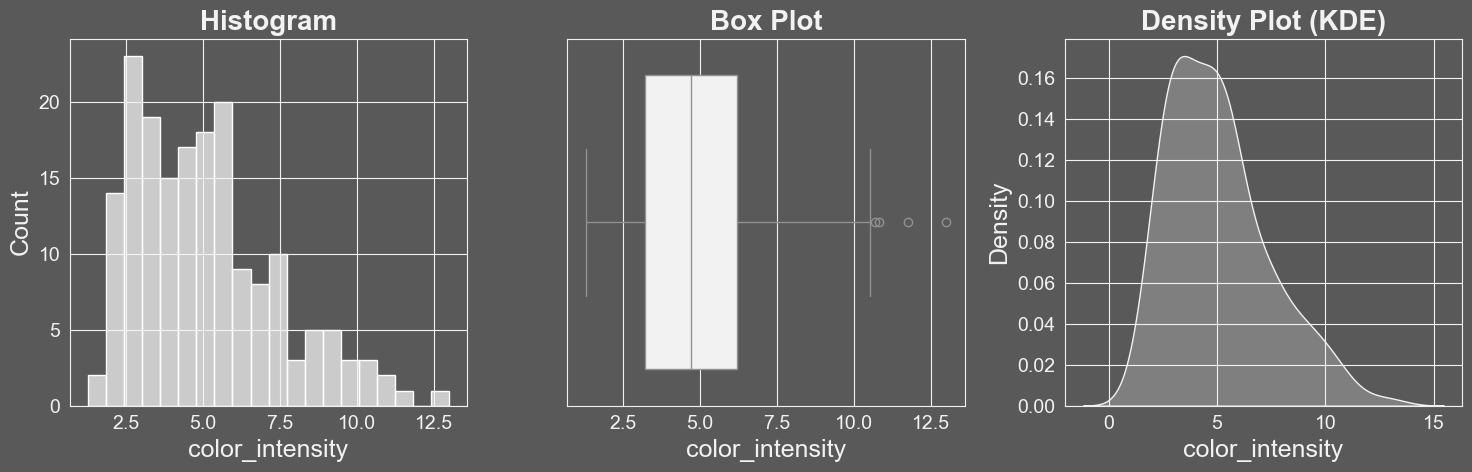

In [116]:
# Compare methods in subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram
sns.histplot(df['color_intensity'], kde=False, bins=20, ax=axes[0], color="#f2f2f2")
axes[0].set_title('Histogram', color="#f2f2f2")

# Box Plot
sns.boxplot(x=df['color_intensity'], ax=axes[1], color="#f2f2f2")
axes[1].set_title('Box Plot', color="#f2f2f2")

# Density Plot (KDE)
sns.kdeplot(df['color_intensity'], ax=axes[2], fill=True, color="#f2f2f2")
axes[2].set_title('Density Plot (KDE)', color="#f2f2f2")

plt.tight_layout()
plt.show()

### Relationships between features

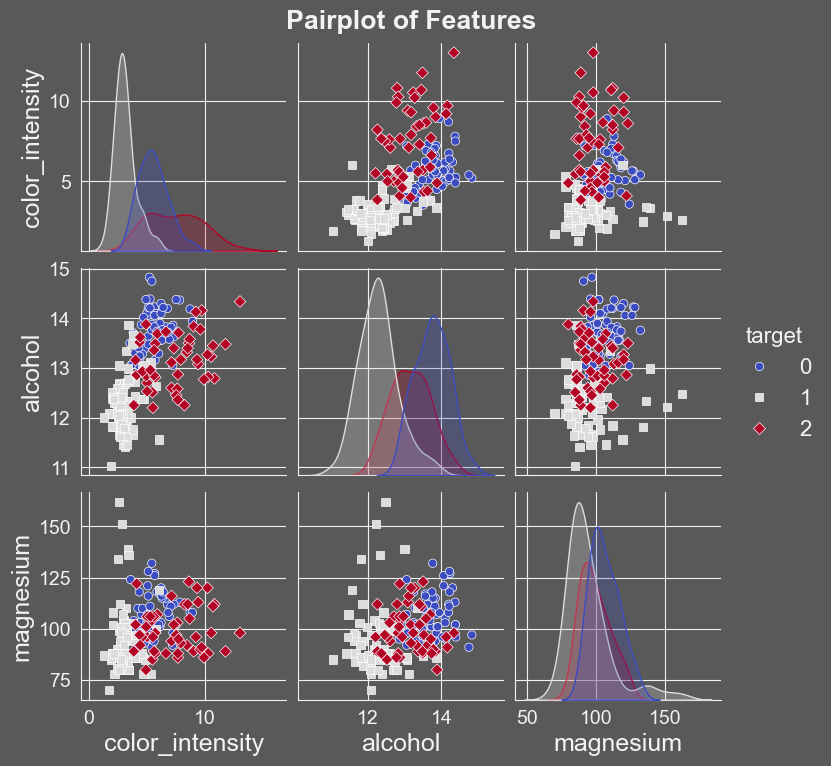

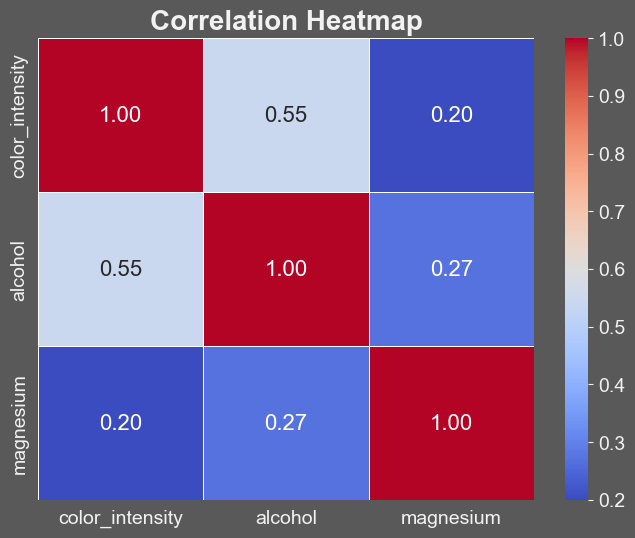

In [118]:
# Create pair plot for relationships between features
sns.pairplot(df[['color_intensity', 'alcohol', 'magnesium','target']], hue="target", palette="coolwarm", markers=["o", "s", "D"])
plt.suptitle("Pairplot of Features", weight="bold", y=1.02)
plt.show()

# Plot correlation heatmap
corr = df[['color_intensity', 'alcohol','magnesium']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap", weight="bold")
plt.show()


### Handling missing data and outliers

Text(0.5, 1.0, 'Boxplot for Outliers')

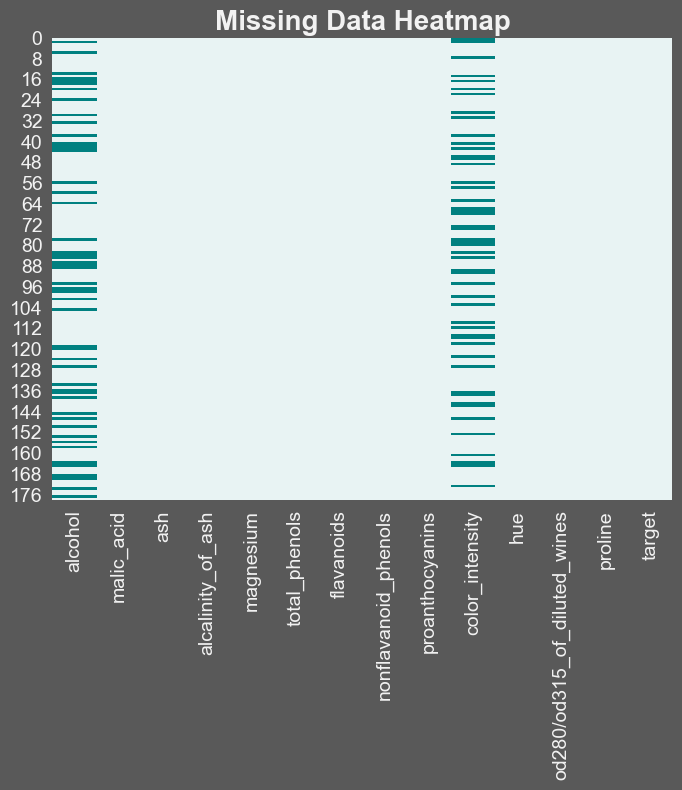

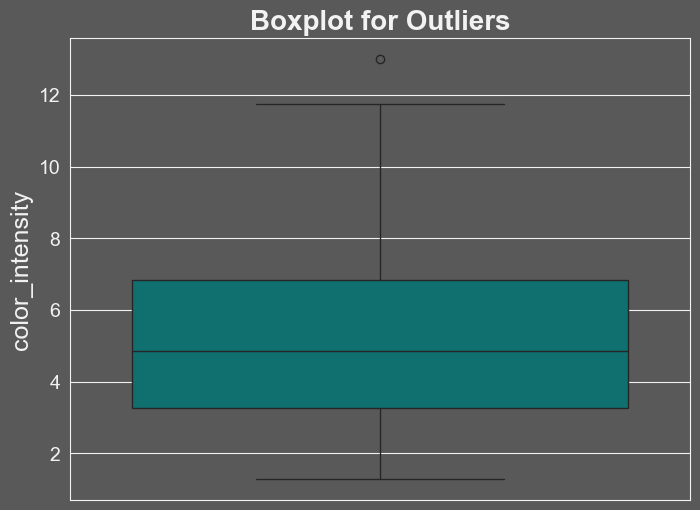

In [120]:
# Introduce random missing values in both features only if there are no existing NaN values
# Create a copy for missing data analysis
data = df.copy()
# Check for existing missing values
existing_missing_values = data.isnull().sum()

if existing_missing_values.any() == 0:
    missing_indices_1 = np.random.choice(data.index, size=50, replace=False)  # 50 random NaNs in Feature 1
    missing_indices_2 = np.random.choice(data.index, size=50, replace=False)  # 50 random NaNs in Feature 2

    # Set NaNs for the selected indices
    data.loc[missing_indices_1, 'color_intensity'] = np.nan  
    data.loc[missing_indices_2, 'alcohol'] = np.nan  

# Heatmap for missing data
plt.figure(figsize=(8, 6))
sns.heatmap(data.isnull(), cbar=False, cmap=sns.light_palette("#008080", as_cmap=True))  # Custom teal
plt.title('Missing Data Heatmap', color="#f2f2f2")

# Boxplot for Outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=data['color_intensity'], color='teal')
plt.title('Boxplot for Outliers', color="#f2f2f2", fontsize=20, fontweight="bold")


## High-dimensional data

### Curse of Dimensionality
As dimensions increase, data becomes more sparse and harder to interpret.

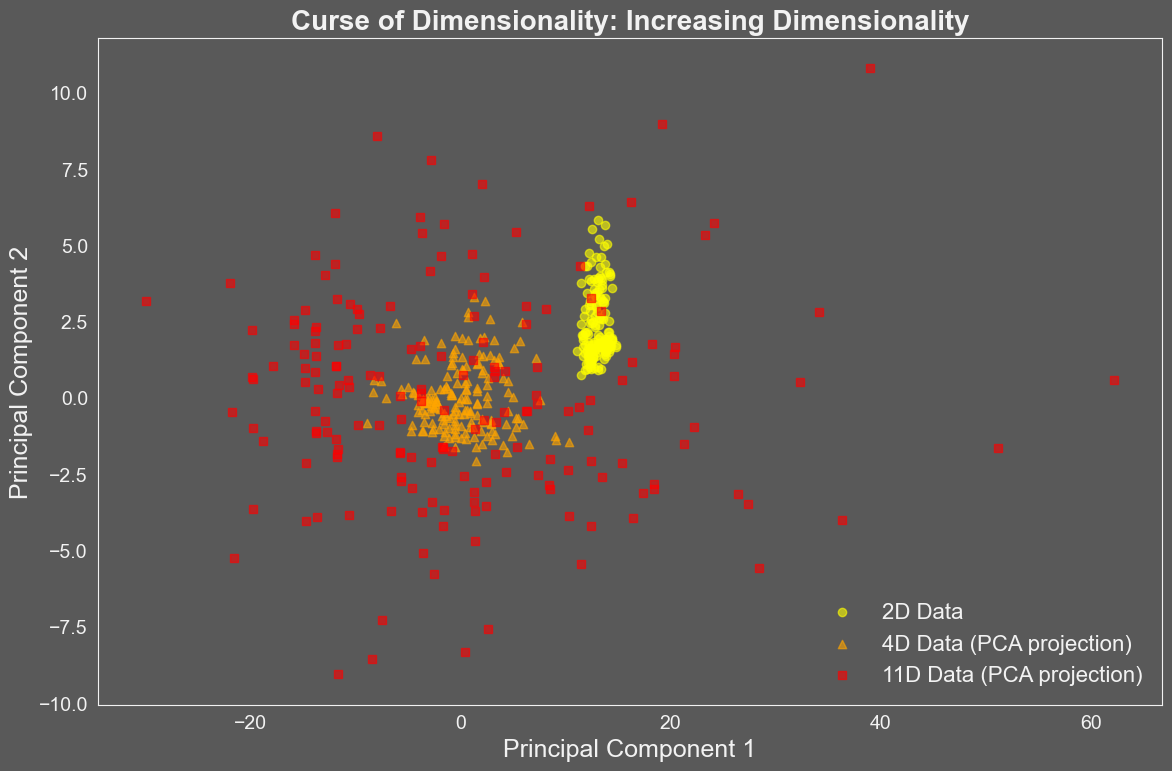

In [123]:
X = wine.data  # Features of the wine dataset
y = wine.target  # Target labels

# Select subsets of 2, 5, and 11 features
X_2d = X[:, :2]  # First 2 features
X_4d = X[:, :4]  # First 5 features
X_11d = X[:, :11]  # First 11 features

# Apply PCA to project 4D and 11D data to 2D for visualisation
pca_4d = PCA(n_components=2)
X_4d_pca = pca_4d.fit_transform(X_4d)

pca_11d = PCA(n_components=2)
X_11d_pca = pca_11d.fit_transform(X_11d)

# Set up the figure for a single slide
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plots for different dimensionalities
ax.scatter(X_2d[:, 0], X_2d[:, 1], c='yellow', label="2D Data", alpha=0.6, marker='o')
ax.scatter(X_4d_pca[:, 0], X_4d_pca[:, 1], c='orange', label="4D Data (PCA projection)", alpha=0.6, marker='^')
ax.scatter(X_11d_pca[:, 0], X_11d_pca[:, 1], c='red', label="11D Data (PCA projection)", alpha=0.6, marker='s')

# Labels and title
ax.set_title("Curse of Dimensionality: Increasing Dimensionality")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(loc="best")
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

### Cost of dimensionality to performance and computational time

Dimensions: 1, Train Accuracy: 0.7097, Test Accuracy: 0.6667, Time: 0.0009 seconds
Dimensions: 2, Train Accuracy: 0.7742, Test Accuracy: 0.7222, Time: 0.0006 seconds
Dimensions: 3, Train Accuracy: 0.7742, Test Accuracy: 0.7407, Time: 0.0029 seconds
Dimensions: 4, Train Accuracy: 0.6935, Test Accuracy: 0.5926, Time: 0.0006 seconds
Dimensions: 5, Train Accuracy: 0.5645, Test Accuracy: 0.5000, Time: 0.0012 seconds
Dimensions: 6, Train Accuracy: 0.5726, Test Accuracy: 0.5000, Time: 0.0006 seconds
Dimensions: 7, Train Accuracy: 0.5726, Test Accuracy: 0.5185, Time: 0.0006 seconds
Dimensions: 8, Train Accuracy: 0.5726, Test Accuracy: 0.5185, Time: 0.0006 seconds
Dimensions: 9, Train Accuracy: 0.5645, Test Accuracy: 0.5185, Time: 0.0007 seconds
Dimensions: 10, Train Accuracy: 0.5645, Test Accuracy: 0.5185, Time: 0.0006 seconds
Dimensions: 11, Train Accuracy: 0.5645, Test Accuracy: 0.5185, Time: 0.0007 seconds


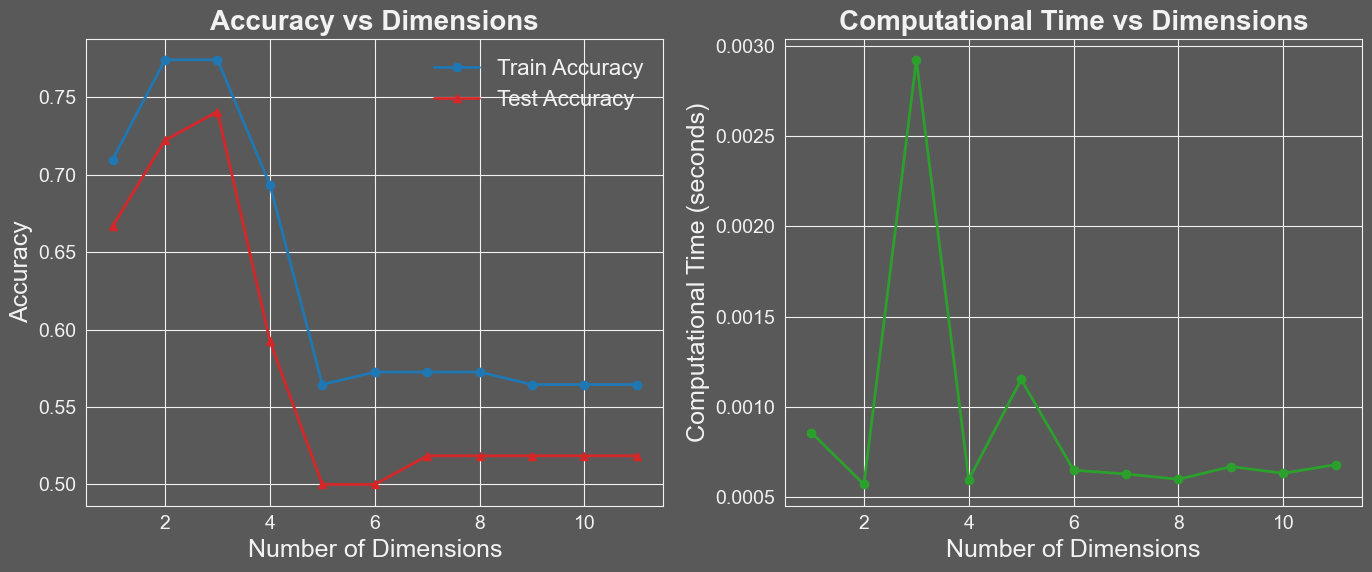

In [125]:
# Set data
X_full, y = wine.data, wine.target

# Set up the number of features (1 to 11)
dimensions = list(range(1, 12))  # Dimensions from 1 to 11
train_accuracies = []
test_accuracies = []
computational_times = []

# Loop through different dimensions to observe the Curse of Dimensionality
for dim in dimensions:
    # Select the first 'dim' features
    X = X_full[:, :dim]
    
    # Train-test split (70% training, 30% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Initialize the SVM model with a Radial Basis Function (RBF) kernel
    model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
    
    # Start timing the training
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    
    # Predict on both train and test sets
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Calculate accuracy on the train and test set
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    # Track accuracies and computational cost (training time)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    computational_times.append(end_time - start_time)

    # Print the status (debugging purpose)
    print(f"Dimensions: {dim}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}, Time: {end_time - start_time:.4f} seconds")

# Create two subplots: one for accuracy and one for computational time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy vs Dimensions plot (Training vs Test Accuracy)
ax1.plot(dimensions, train_accuracies, color='tab:blue', marker='o', label='Train Accuracy',linewidth=2)
ax1.plot(dimensions, test_accuracies, color='tab:red', marker='^', label='Test Accuracy',linewidth=2)
ax1.set_xlabel('Number of Dimensions')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs Dimensions')
ax1.legend()
ax1.grid(True)

# Computational Time vs Dimensions plot
ax2.plot(dimensions, computational_times, color='tab:green', marker='o', label='Computational Time',linewidth=2)
ax2.set_xlabel('Number of Dimensions')
ax2.set_ylabel('Computational Time (seconds)')
ax2.set_title('Computational Time vs Dimensions')
ax2.grid(True)

# Adjust layout
fig.tight_layout()

# Show the plot
plt.show()

### Dimensionality reduction techniques: 
Pricipal Component Analysis (PCA)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

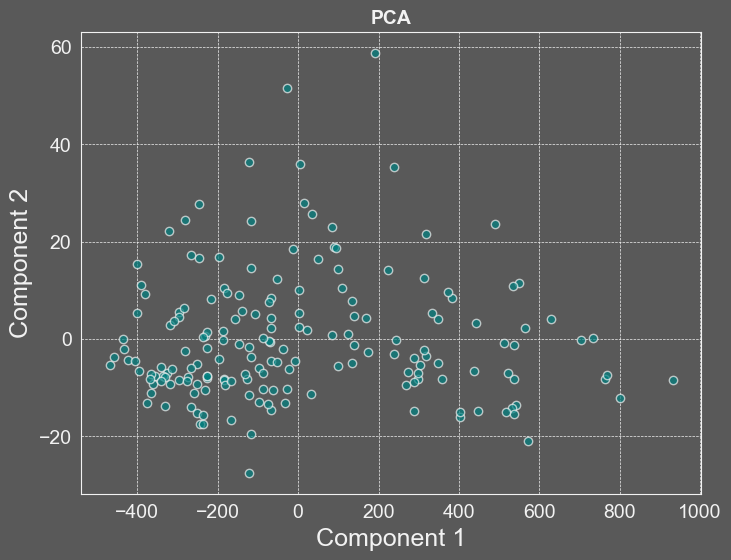

In [166]:
print(df.head())
# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df)

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))  # Define ax properly

# Common plot settings
scatter_kwargs = {'c': 'teal', 'edgecolor': '#f2f2f2', 'alpha': 0.7}

# Plot PCA
ax.scatter(pca_result[:, 0], pca_result[:, 1], **scatter_kwargs)
ax.set_title('PCA', fontsize=14, fontweight='bold')
ax.set_xlabel('Component 1')  # Commented as per your original code
ax.set_ylabel('Component 2')
ax.grid(True, linestyle='--', linewidth=0.5)

plt.show()

### Dimensionality reduction techniques: 
t-Distributed Stochastic Neighbor Embedding (t-SNE) and Uniform Manifold Approximation and Projection (UMAP)

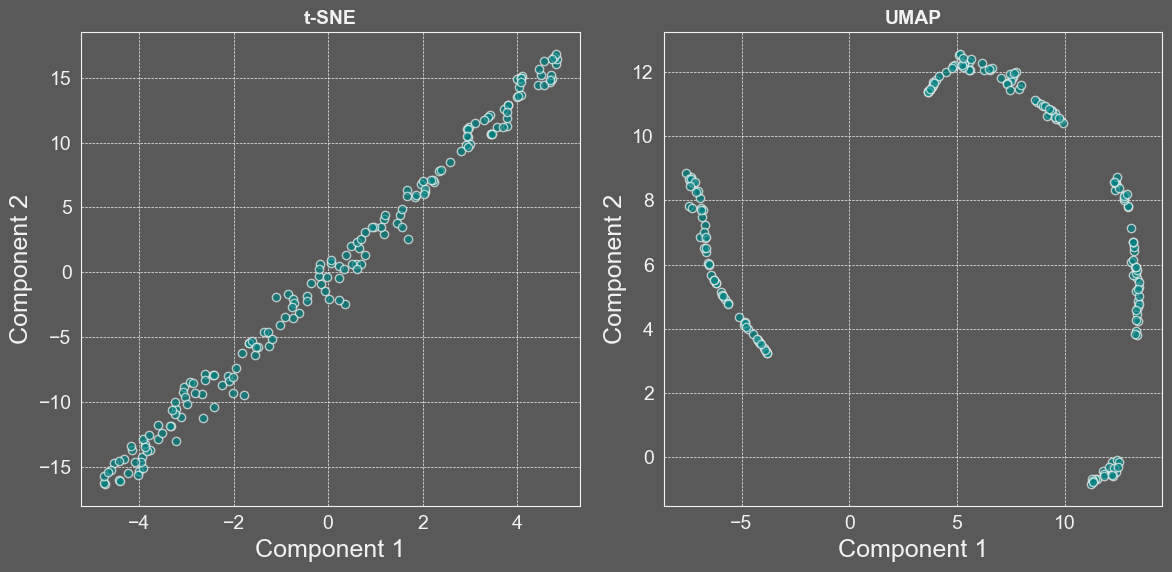

In [129]:
# Apply t-SNE with explicit parameters
tsne = TSNE(n_components=2, init='random', learning_rate='auto')  # Avoid FutureWarning
tsne_result = tsne.fit_transform(df)

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(df)

# Create a subplot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Common plot settings
scatter_kwargs = {'c': 'teal', 'edgecolor': '#f2f2f2', 'alpha': 0.7}

# Plot t-SNE
ax[0].scatter(tsne_result[:, 0], tsne_result[:, 1], **scatter_kwargs)
ax[0].set_title('t-SNE', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Component 1')
ax[0].set_ylabel('Component 2')
ax[0].grid(True, linestyle='--', linewidth=0.5)

# Plot UMAP
ax[1].scatter(umap_result[:, 0], umap_result[:, 1], **scatter_kwargs)
ax[1].set_title('UMAP', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Component 1')
ax[1].set_ylabel('Component 2')
ax[1].grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

### Feature distributions & transformations

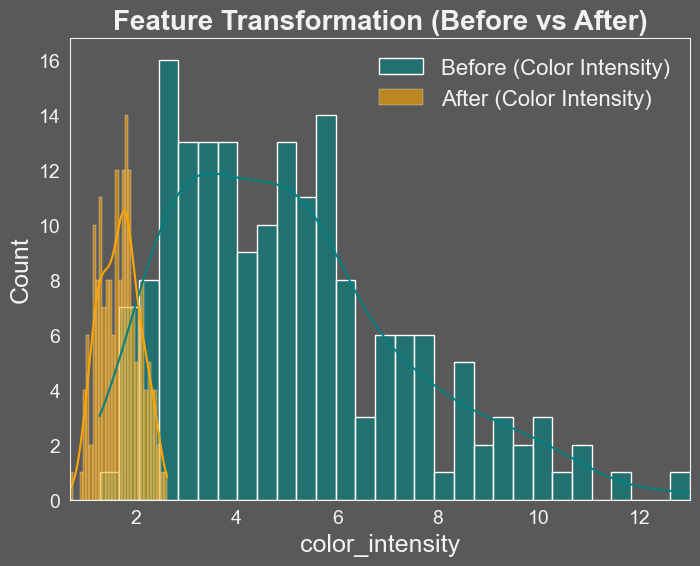

In [131]:
# Select the relevant feature: color_intensity
data = df[['color_intensity']].copy()

# Apply log transformation (handle potential negative values)
# For log transformation, we use np.log1p for stability (log(x+1))
data['Transformed Color Intensity'] = np.log1p(data['color_intensity'] - data['color_intensity'].min() + 1)

# Plot before and after transformation
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x='color_intensity', bins=30, kde=True, color='teal', label='Before (Color Intensity)', alpha=0.6)
sns.histplot(data=data, x='Transformed Color Intensity', bins=30, kde=True, color='orange', label='After (Color Intensity)', alpha=0.6)

plt.title("Feature Transformation (Before vs After)", fontsize=20, weight="bold")
plt.legend()
plt.xlim(min(data['color_intensity'].min(), data['Transformed Color Intensity'].min()), 
         max(data['color_intensity'].max(), data['Transformed Color Intensity'].max()))
plt.grid(False)

plt.show()

### Feature transformations (Log, Standardisation, and Normalisation) 

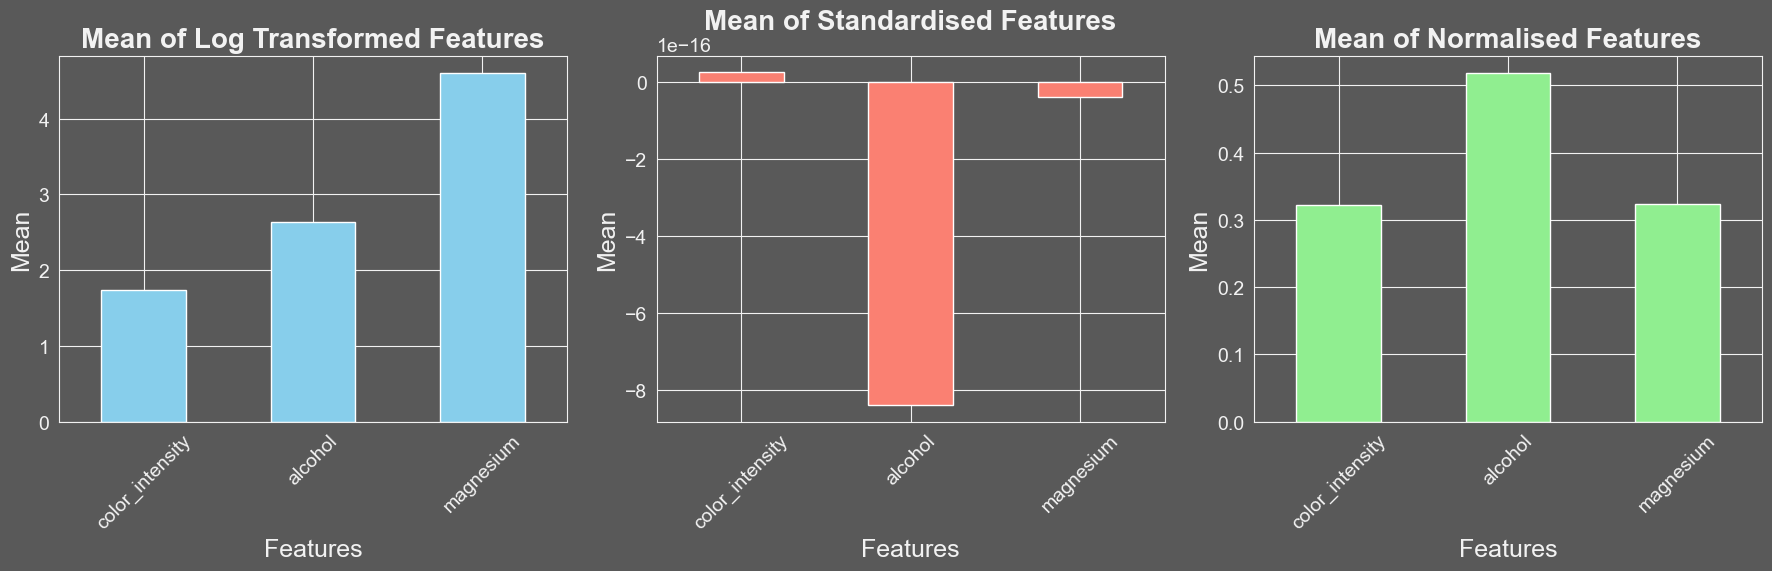

In [133]:
# Log Transformation
df_log = df[['color_intensity', 'alcohol', 'magnesium']].copy()  # Add parentheses to call copy
df_log[df_log.columns] = np.log1p(df_log[df_log.columns])  # Log transform all selected columns

# Standardisation (Z-Score Normalisation)
scaler = StandardScaler()
df_standardised = df[['color_intensity', 'alcohol', 'magnesium']].copy()
df_standardised[df_standardised.columns] = scaler.fit_transform(df_standardised[df_standardised.columns])

# Normalisation (Min-Max Scaling)
scaler = MinMaxScaler()
df_normalised = df[['color_intensity', 'alcohol', 'magnesium']].copy()
df_normalised[df_normalised.columns] = scaler.fit_transform(df_normalised[df_normalised.columns])

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Log Transformed Data Bar Plot
df_log.mean().plot(kind='bar', color='skyblue', ax=axes[0])
axes[0].set_title('Mean of Log Transformed Features')
axes[0].set_ylabel('Mean')
axes[0].set_xlabel('Features')
axes[0].tick_params(axis='x', rotation=45)


# Standardised Data Bar Plot
df_standardised.mean().plot(kind='bar', color='salmon', ax=axes[1])
axes[1].set_title('Mean of Standardised Features')
axes[1].set_ylabel('Mean')
axes[1].set_xlabel('Features')
axes[1].tick_params(axis='x', rotation=45)

# Normalised Data Bar Plot
df_normalised.mean().plot(kind='bar', color='lightgreen', ax=axes[2])
axes[2].set_title('Mean of Normalised Features')
axes[2].set_ylabel('Mean')
axes[2].set_xlabel('Features')
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

### Feature Importance & Selection

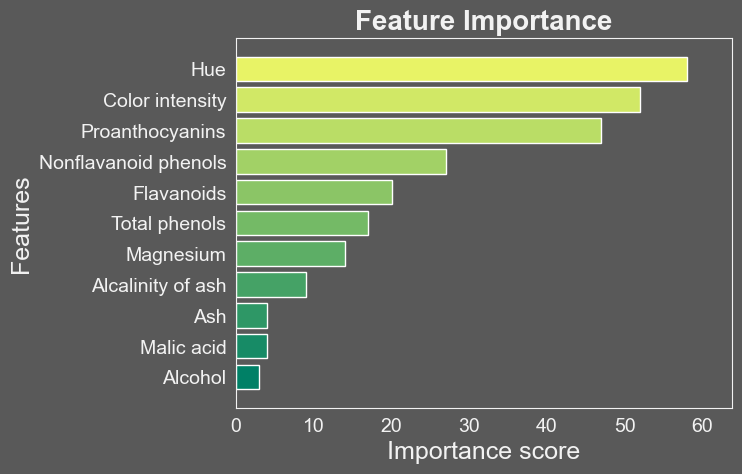

In [135]:
# Set the Wine dataset
X = wine.data
y = wine.target

# Create DataFrame with all features and the target 'Class'
data = pd.DataFrame(X, columns=wine.feature_names)
data['Class'] = y

# Train an XGBoost model
model = xgb.XGBClassifier(random_state=42)
model.fit(X, y)

# Plot feature importance
ax = xgb.plot_importance(
    model, 
    importance_type='weight',  # Feature importance type
    max_num_features=11,       # Display top 11 features
    title='Feature Importance', # Title for the plot
    height=0.8,                # Bar height
    show_values=False            # Show feature importance values
)

# Manually apply the colormap
for i, patch in enumerate(ax.patches):
    patch.set_facecolor(plt.cm.summer(i / len(ax.patches)))  # Applying colormap

# Set the feature names from wine.feature_names
modified_feature_names = [name.replace('_', ' ').capitalize() for name in wine.feature_names[:11]]
ax.set_yticklabels(modified_feature_names)

# Show the plot
plt.grid(False)
plt.show()


### Model evaluation

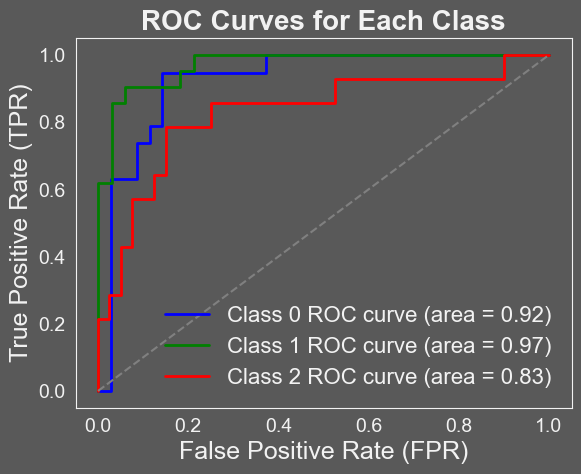

In [137]:
# Set the Wine dataset
X = wine.data
y = wine.target

# Select the 3 weakest features: 'ash', 'alcohol', and 'malic_acid'
feature_indices = [wine.feature_names.index('ash'),
                   wine.feature_names.index('alcohol'),
                   wine.feature_names.index('malic_acid')]

X_weak = X[:, feature_indices]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_weak, y, test_size=0.3, random_state=42)

# Initialize a Logistic Regression classifier (or another classifier if you prefer)
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

# Binarize the labels for multi-class ROC curve (one-hot encoding)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Compute the ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC curve and AUC for each class
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], clf.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure()
colors = ['blue', 'green', 'red']
for i in range(3):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f'Class {i} ROC curve (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curves for Each Class")
plt.legend(loc="lower right")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.grid(False)

plt.show()


### Decision boundaries

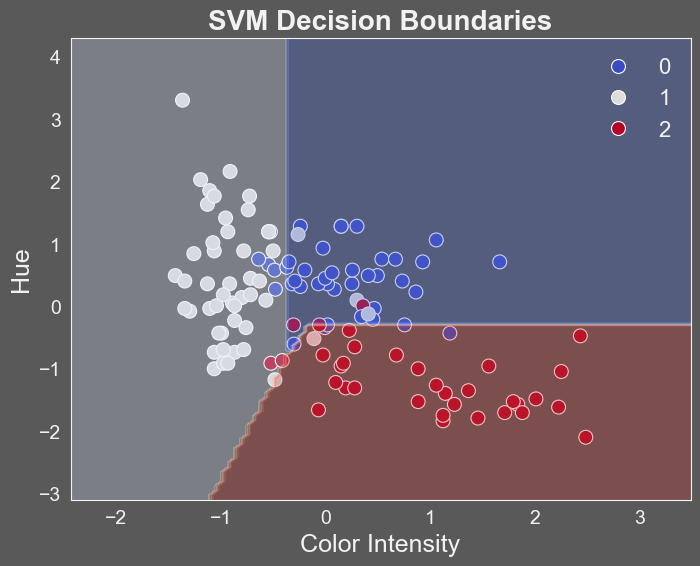

In [139]:
# Select the 'color_intensity' and 'hue' features for simplicity
X = df[['color_intensity', 'hue']].copy()
y = wine.target

# Standardize the data (SVM is sensitive to feature scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train an SVM classifier with a linear kernel
clf = SVC(kernel='linear')
clf.fit(X_train, y_train)

# Create a meshgrid for plotting decision boundaries
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict class labels for each point in the meshgrid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary and data points
plt.figure(figsize=(8, 6))
ax = plt.gca()
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, palette='coolwarm', ax=ax, s=100)
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
ax.set_title('SVM Decision Boundaries')
plt.xlabel('Color Intensity')
plt.ylabel('Hue')
plt.grid(False)

plt.show()

## Tuning of model parameters

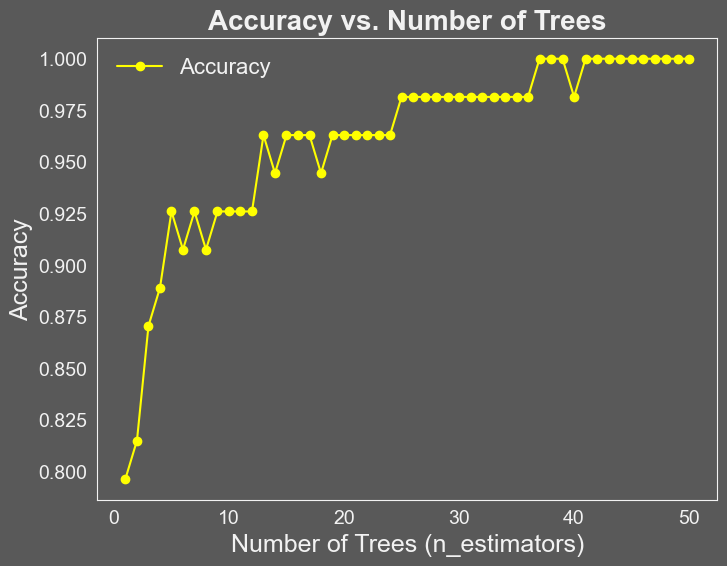

In [162]:
# Specify the Wine dataset
X = wine.data
y = wine.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# List to store the accuracy for each number of trees
n_estimators_range = range(1, 51)  # Number of trees from 1 to 100
accuracies = []

# Loop through different numbers of trees (n_estimators)
for n_estimators in n_estimators_range:
    # Initialize RandomForest with the current number of trees
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    
    # Train the model
    rf.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = rf.predict(X_test)
    
    # Calculate the accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Append the accuracy to the list
    accuracies.append(accuracy)

# Plot the accuracy as a function of the number of trees
plt.figure(figsize=(8, 6))
plt.plot(n_estimators_range, accuracies, marker='o', color='yellow', label='Accuracy')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Trees')
plt.grid(False)
plt.legend()
plt.show()
